Data Preprocessing

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
from sklearn.naive_bayes import GaussianNB
#from tensorflow.keras.utils import to_categorical

In [16]:
# Reading in the datasets
additional_test = pd.read_csv('test/Features/additional_features.csv')
color_test = pd.read_csv('test/Features/color_histogram.csv')
hog_test = pd.read_csv('test/Features/hog_pca.csv')
testing = pd.read_csv('test/test_metadata.csv')

additional_train = pd.read_csv('train/Features/additional_features.csv')
color_train = pd.read_csv('train/Features/color_histogram.csv')
hog_train = pd.read_csv('train/Features/hog_pca.csv')
training = pd.read_csv('train/train_metadata.csv')


# PREPROCESSING THE DATA

# Standardising additional_features 
additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler_additional = StandardScaler()
additional_train[additional_features_columns] = scaler_additional.fit_transform(additional_train[additional_features_columns])
additional_test[additional_features_columns] = scaler_additional.transform(additional_test[additional_features_columns])

# Standardising color histograms
color_columns = [col for col in color_train.columns if col.startswith("ch_")]
scaler_color = StandardScaler()
color_train[color_columns] = scaler_color.fit_transform(color_train[color_columns])
color_test[color_columns] = scaler_color.transform(color_test[color_columns])

# Once preprocessed, we can now merge the features together for the training metadata set
combined_training = pd.merge(training, additional_train, on='image_path')
combined_training = pd.merge(combined_training, color_train, on='image_path')
combined_training = pd.merge(combined_training, hog_train, on='image_path')
combined_training = combined_training[[col for col in combined_training.columns if col != 'ClassId'] + ['ClassId']]

# Same for the testing metadata set
combined_testing = pd.merge(testing, additional_test, on='image_path')
combined_testing = pd.merge(combined_testing, color_test, on='image_path')  
combined_testing = pd.merge(combined_testing, hog_test, on='image_path')
combined_testing = combined_testing[[col for col in combined_testing.columns if col != 'ClassId'] + ['ClassId']]


# FEATURE SELECTION via Mutual Information
def apply_mutual_info_filtering(combined_training, top_k=50):
    X = combined_training.drop(columns=['id', 'image_path', 'ClassId'])
    y = combined_training['ClassId']
    
    mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
    mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi_scores})
    mi_df_sorted = mi_df.sort_values(by='mutual_info', ascending=False)
    top_features = mi_df_sorted.head(top_k)['feature'].tolist()
    
    return combined_training[top_features + ['ClassId']], mi_df_sorted


print("Applying Mutual Information Filtering to Training Data:")
training_filtered, mi_df_train_sorted = apply_mutual_info_filtering(combined_training, top_k=50)
print("Top 50 Features based on Mutual Information:")

testing_filtered = combined_testing[training_filtered.columns.tolist()]


Applying Mutual Information Filtering to Training Data:
Top 50 Features based on Mutual Information:


Best KNN Model Accuracy on Additional Features: 0.2787 with parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.25      0.29      0.27        62
           2       0.24      0.21      0.22        63
           3       0.22      0.26      0.24        39
           4       0.25      0.31      0.28        55
           5       0.30      0.25      0.27        52
           6       0.42      0.42      0.42        12
           7       0.28      0.33      0.30        40
           8       0.33      0.41      0.37        39
           9       0.19      0.20      0.19        41
          10       0.30      0.32      0.31        56
          11       0.13      0.11      0.12        37
          12       0.38      0.31      0.34        59
          13       0.36      0.35      0.35        60
          14       0.25      0.32      0.28        2

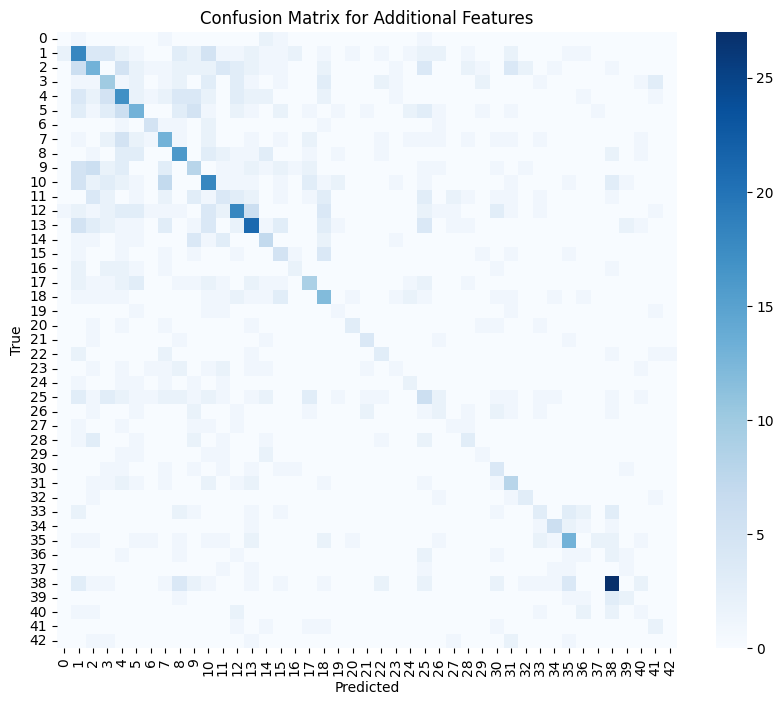

C:\Users\asus\AppData\Local\Temp\ipykernel_28020\4100120967.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_additional, x='ClassId', palette='viridis')


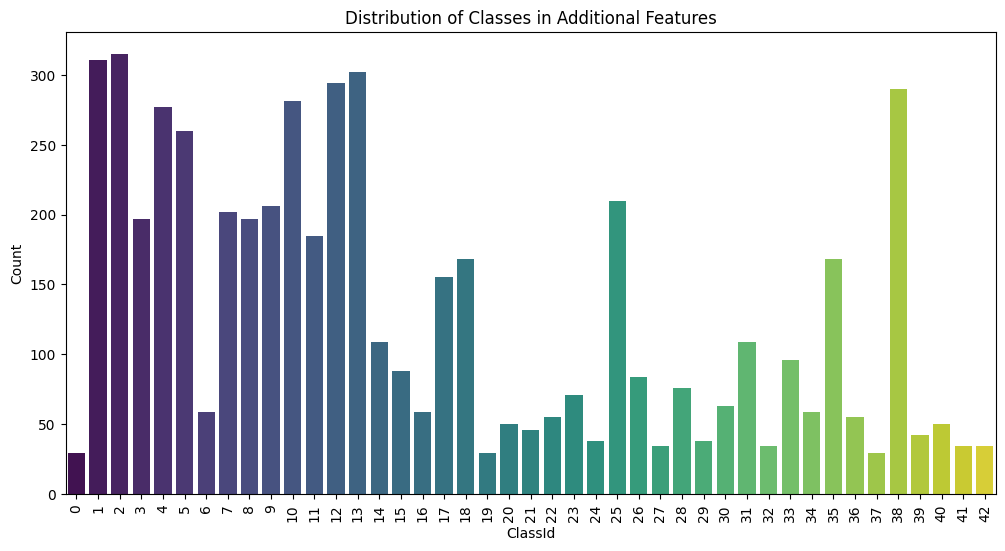

In [17]:
# run on additional features
additional_train = pd.read_csv('train/Features/additional_features.csv')

additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler = StandardScaler()
additional_train[additional_features_columns] = scaler.fit_transform(additional_train[additional_features_columns])


training = pd.read_csv('train/train_metadata.csv')
# Merge additional features with training metadata
combined_additional = pd.merge(training, additional_train, on='image_path')
combined_additional = combined_additional.drop(columns=['id', 'image_path'])

X_additional = combined_additional.drop(columns=['ClassId']).values
Y_additional = combined_additional['ClassId'].values

# Split the data into training and validation sets
X_train_additional, X_val_additional, Y_train_additional, Y_val_additional = train_test_split(
    X_additional, Y_additional, test_size=0.2, random_state=123, stratify=Y_additional
)

# KNN on additional features
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_additional, Y_train_additional)
best_knn = grid_search.best_estimator_

# Evaluate the best KNN model on the validation set
Y_val_pred_additional = best_knn.predict(X_val_additional)
accuracy_additional = accuracy_score(Y_val_additional, Y_val_pred_additional)
print(f"Best KNN Model Accuracy on Additional Features: {accuracy_additional:.4f}", "with parameters:", grid_search.best_params_)
# Classification report for additional features
print(classification_report(Y_val_additional, Y_val_pred_additional))
# Confusion matrix for additional features
conf_matrix_additional = confusion_matrix(Y_val_additional, Y_val_pred_additional)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_additional, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Additional Features")
plt.show()

# show distribution of classes in additional features
plt.figure(figsize=(12, 6))
sns.countplot(data=combined_additional, x='ClassId', palette='viridis')
plt.title('Distribution of Classes in Additional Features')
plt.xlabel('ClassId')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()




Best KNN Model Accuracy on HOG PCA Features: 0.7668 with parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.50      0.17      0.25         6
           1       0.74      0.63      0.68        62
           2       0.54      0.68      0.60        63
           3       0.51      0.54      0.53        39
           4       0.60      0.64      0.62        55
           5       0.65      0.62      0.63        52
           6       0.91      0.83      0.87        12
           7       0.61      0.68      0.64        40
           8       0.70      0.79      0.75        39
           9       0.81      0.95      0.88        41
          10       0.90      0.82      0.86        56
          11       0.54      0.70      0.61        37
          12       1.00      0.98      0.99        59
          13       1.00      1.00      1.00        60
          14       1.00      0.82      0.90        22
 

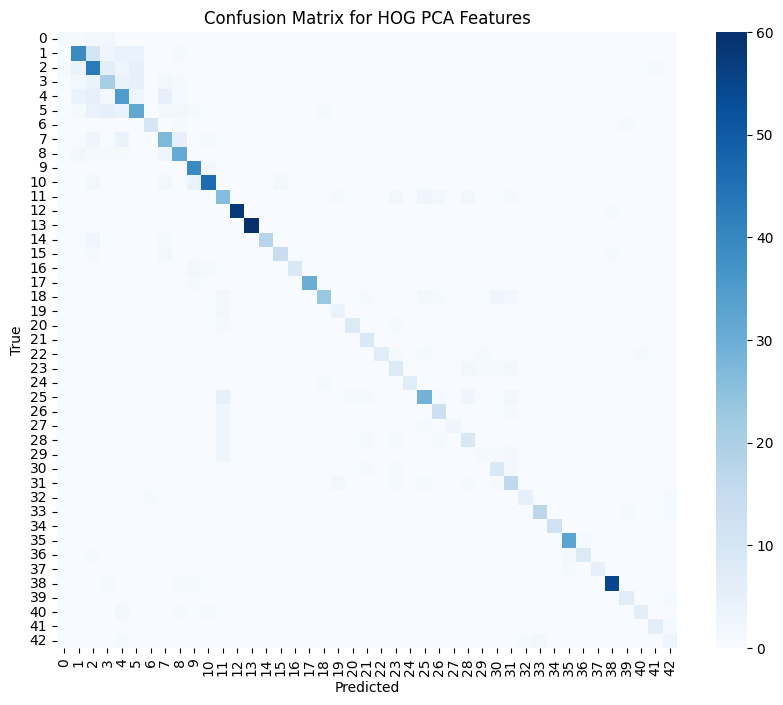

In [18]:
# run knn on hog pca features
hog_train = pd.read_csv('train/Features/hog_pca.csv')
hog_columns = [col for col in hog_train.columns if col != 'image_path']
scaler = StandardScaler()
hog_train[hog_columns] = scaler.fit_transform(hog_train[hog_columns])

training = pd.read_csv('train/train_metadata.csv')
# Merge HOG PCA features with training metadata
combined_hog = pd.merge(training, hog_train, on='image_path')

combined_hog = combined_hog.drop(columns=['id', 'image_path'])
X_hog = combined_hog.drop(columns=['ClassId']).values
Y_hog = combined_hog['ClassId'].values
# Split the data into training and validation sets
X_train_hog, X_val_hog, Y_train_hog, Y_val_hog = train_test_split(
    X_hog, Y_hog, test_size=0.2, random_state=123, stratify=Y_hog
)

# KNN on HOG PCA features
knn_hog = KNeighborsClassifier()
param_grid_hog = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_hog = GridSearchCV(knn_hog, param_grid_hog, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_hog.fit(X_train_hog, Y_train_hog)
best_knn_hog = grid_search_hog.best_estimator_
# Evaluate the best KNN model on the validation set
Y_val_pred_hog = best_knn_hog.predict(X_val_hog)
accuracy_hog = accuracy_score(Y_val_hog, Y_val_pred_hog)
print(f"Best KNN Model Accuracy on HOG PCA Features: {accuracy_hog:.4f}", "with parameters:", grid_search_hog.best_params_)
# Classification report for HOG PCA features
print(classification_report(Y_val_hog, Y_val_pred_hog))
# Confusion matrix for HOG PCA features
conf_matrix_hog = confusion_matrix(Y_val_hog, Y_val_pred_hog)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_hog, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for HOG PCA Features")
plt.show()



Test Accuracy: 0.599271402550091


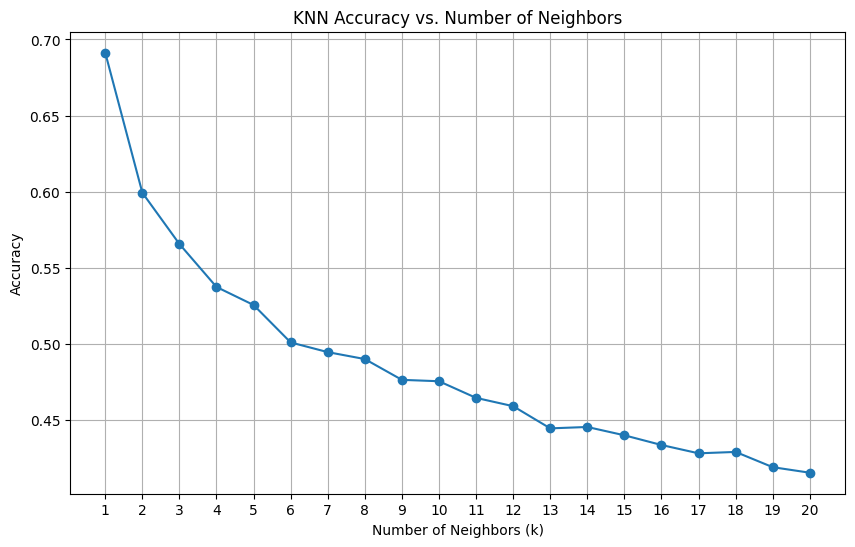

In [19]:
import pandas as pd
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Parameters
image_size = (32, 32)
image_dir = 'train/Images'
metadata_path = 'train/train_metadata.csv'

# Load metadata
metadata = pd.read_csv(metadata_path)

# Load and preprocess images
def load_images_from_metadata(metadata, image_dir, image_size=(32, 32)):
    X, y = [], []
    for _, row in metadata.iterrows():
        filename = row['image_path']
        label = row['ClassId']
        filepath = os.path.join(image_dir, filename)
        img = cv2.imread(filepath)
        if img is not None:
            try:
                img = cv2.resize(img, image_size)
                X.append(img)
                y.append(label)
            except:
                print(f"Skipping image due to resize failure: {filename}")
        else:
            print(f"Failed to load image: {filename}")
    return np.array(X).astype(np.float32), np.array(y)

# Load data
X, y = load_images_from_metadata(metadata, image_dir)
X = X / 255.0  # Normalize pixel values
X = X.reshape(X.shape[0], -1)  # Flatten for KNN

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and test KNN
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# visualise accuracy of KNN of k = 1 to k = 20
k_values = np.arange(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()


Benchmark Model

In [20]:
from sklearn.dummy import DummyClassifier

X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)


dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)
y_dummy = dummy.predict(X_val)
print("Baseline Accuracy:", accuracy_score(Y_val, y_dummy))

Baseline Accuracy: 0.058287795992714025


Neural Network Model

In [21]:
# NEURAL NETWORK
X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

m, n = X_train.shape

shuffled_df = training_filtered.sample(frac=1, random_state=42).reset_index(drop=True)
X_train = shuffled_df.drop(columns=['ClassId']).to_numpy()
Y_train = shuffled_df['ClassId'].to_numpy()
X = X_train.T

numInputs = X.shape[0]
numHidden = 256
numOutput = 43


# Probably a good idea to integrate some form of dropout here
# Necessary functions for the neural network
def init_params():
    W1 = np.random.randn(numHidden, numInputs) * np.sqrt(2. / numInputs)
    b1 = np.zeros((numHidden, 1))
    W2 = np.random.randn(numOutput, numHidden) * np.sqrt(2. / numHidden)
    b2 = np.zeros((numOutput, 1))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2, dropout_rate=0.5, training=True):
    Z1 = np.dot(W1, X) + b1
    A1 = np.maximum(0, Z1)  # ReLU

    if training:
        # Dropout mask: 1 with probability (1 - dropout_rate), 0 otherwise
        dropout_mask = (np.random.rand(*A1.shape) > dropout_rate).astype(float)
        A1 *= dropout_mask  # Apply mask
        A1 /= (1 - dropout_rate)  # Inverted dropout scaling

    Z2 = np.dot(W2, A1) + b2
    exp_scores = np.exp(Z2 - np.max(Z2, axis=0, keepdims=True))
    A2 = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
    return A1, A2


def backward_propagation(X, Y, A1, A2, W1, W2):
    m = X.shape[1]
    dZ2 = A2 - Y 
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * (A1 > 0)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def one_hot_encode(Y, num_classes):
    m = Y.shape[0]
    Y_encoded = np.zeros((num_classes, m))
    Y_encoded[Y, np.arange(m)] = 1
    return Y_encoded

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

def get_accuracy(A2, Y):
    predictions = np.argmax(A2, axis=0)
    accuracy = np.mean(predictions == Y)
    return accuracy*100

def predict(A2):
    return np.argmax(A2, axis=0)

def gradient_descent(X, Y, W1, b1, W2, b2, learning_rate=0.01, epochs=1000, dropout_rate=0.5):
    Y_encoded = one_hot_encode(Y, numOutput)
    for epoch in range(epochs):
        # Apply dropout only during training
        A1, A2 = forward_propagation(X, W1, b1, W2, b2, dropout_rate=dropout_rate, training=True)

        dW1, db1, dW2, db2 = backward_propagation(X, Y_encoded, A1, A2, W1, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        if epoch % 100 == 0:
            A1_val, A2_val = forward_propagation(X, W1, b1, W2, b2, training=False)
            log_probs = -np.log(A2_val[Y, np.arange(Y.shape[0])])
            loss = np.mean(log_probs)
            acc = get_accuracy(A2_val, Y)
            print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {acc:.2f}%")

    return W1, b1, W2, b2


X = X_train.T 
Y = Y_train.astype(int)

W1, b1, W2, b2 = gradient_descent(X, Y, *init_params(), learning_rate=0.1, epochs=1000)


# Confusion Matrix

'''
A1, A2 = forward_propagation(X, W1, b1, W2, b2)
Y_pred = predict(A2)
conf_matrix = confusion_matrix(Y_train, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_train, Y_pred))
'''



Epoch 0, Loss: 4.3251, Accuracy: 3.59%
Epoch 100, Loss: 1.7958, Accuracy: 51.37%
Epoch 200, Loss: 1.4530, Accuracy: 59.46%
Epoch 300, Loss: 1.2757, Accuracy: 63.81%
Epoch 400, Loss: 1.1596, Accuracy: 67.06%
Epoch 500, Loss: 1.0743, Accuracy: 69.75%
Epoch 600, Loss: 1.0074, Accuracy: 71.70%
Epoch 700, Loss: 0.9525, Accuracy: 73.54%
Epoch 800, Loss: 0.9068, Accuracy: 74.47%
Epoch 900, Loss: 0.8673, Accuracy: 75.49%


'\nA1, A2 = forward_propagation(X, W1, b1, W2, b2)\nY_pred = predict(A2)\nconf_matrix = confusion_matrix(Y_train, Y_pred)\nplt.figure(figsize=(10, 8))\nsns.heatmap(conf_matrix, annot=False, cmap=\'Blues\', fmt=\'g\')\nplt.xlabel("Predicted")\nplt.ylabel("True")\nplt.title("Confusion Matrix")\nplt.show()\n\nprint(classification_report(Y_train, Y_pred))\n'

In [22]:
# Predicting on the test set
X_test = np.array(testing_filtered.drop(columns=['ClassId']))
X_test_np = X_test.T

_, A2_test = forward_propagation(X_test_np, W1, b1, W2, b2)
predicted_classes = np.argmax(A2_test, axis=0)

NN_output_df = pd.DataFrame({
    'id': combined_testing['id'].values,
    'ClassId': predicted_classes
})

NN_output_df.to_csv('submission.csv', index=False)


Naive Bayes Classification

In [23]:
X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)

nb_model = GaussianNB()
nb_model.fit(X_train_split, Y_train_split)

y_pred_nb = nb_model.predict(X_val)

# Evaluating
print("Naive Bayes Accuracy:", accuracy_score(Y_val, y_pred_nb))
print(classification_report(Y_val, y_pred_nb))

Naive Bayes Accuracy: 0.33576199149969643
              precision    recall  f1-score   support

           0       0.14      0.43      0.21         7
           1       0.44      0.43      0.43        86
           2       0.34      0.36      0.35        84
           3       0.41      0.24      0.30        58
           4       0.29      0.08      0.13        86
           5       0.24      0.05      0.08        79
           6       0.02      0.86      0.04        14
           7       0.44      0.07      0.12        60
           8       0.10      0.08      0.09        64
           9       0.66      0.43      0.52        68
          10       0.30      0.12      0.17        94
          11       0.33      0.14      0.20        56
          12       1.00      0.76      0.86        79
          13       1.00      0.68      0.81        90
          14       0.93      0.79      0.85        33
          15       0.24      0.48      0.32        25
          16       0.53      0.40      

Ensemble Stacking Model

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

X_train = np.array(training_filtered.drop(columns=['ClassId']))
Y_train = np.array(training_filtered['ClassId'])

X_train_split, X_val, Y_train_split, Y_val = train_test_split(X_train, Y_train, test_size=0.3, random_state=42)

# Level-0 base models
rf = RandomForestClassifier(random_state=1)
lr = LogisticRegression(max_iter=1000)
nb = GaussianNB()

# Train base models on training data
rf.fit(X_train, Y_train)
lr.fit(X_train, Y_train)
nb.fit(X_train, Y_train)

# Predict on validation set
rf_pred = rf.predict(X_val)
lr_pred = lr.predict(X_val)
nb_pred = nb.predict(X_val)

# Stack predictions as features for meta-model
meta_X = np.vstack((rf_pred, lr_pred, nb_pred)).T
meta_y = Y_val

# Level-1 meta-model
meta_model = LogisticRegression()
meta_model.fit(meta_X, meta_y)

# Evaluate the stacked model
meta_val_pred = meta_model.predict(meta_X)
print("Stacked Model Accuracy:", accuracy_score(meta_y, meta_val_pred))


# While uncertain about the performance of this model, we can assume it sucks because of the low accuracy of the base models, namely the Naive Bayes model.

Stacked Model Accuracy: 0.3381906496660595


c:\Users\asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
